In [1]:
import sys
sys.path.append('/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/')

import matplotlib.pyplot as plt
import autograd.numpy as np  # Thinly-wrapped numpy
plt.style.use('tableau-colorblind10')


import funcRotor # module for acquiring tidal data from NOAA

import constUnitConvert
CONVERT = constUnitConvert.ConstantsUnitConversion()


This documents guides user on using functions in `funcRotor` to process output files from Aerodyne and to obtain the data below which are necessary to simulate rotor dyanmic 
- function of Power Coefficient, Torque Coefficients, Minimum pressure coefficients, 
- span ratio (corerespinding to the minimum pressure coefficient above), 
- optimal Cp and the corresponding optimal TSR 

In [7]:
AeroDynFolderPath = "/Users/akeow/Desktop/TEAMER HDPS/HDPSTeamer/TurboShipCostCalculator/Original_MHKF1_ARLScaled_20Sections_5ms_VariedPitch_Cp/"

myTSRmax = 10.0
myTSRmin = 0.0
CpFunc,CtFunc,CpminFunc,spanRatio,CpOpt,TSROpt = funcRotor.loadRotorSurfaces(AeroDynFolderPath,myTSRmax,myTSRmin)

bladeVolume,bladeMass,bladeRadius,bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath)

Plot the rotor performanc coefficients

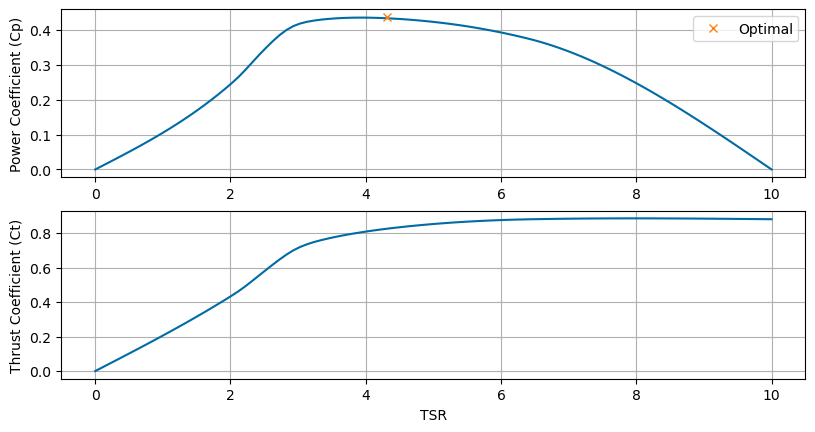

In [8]:
TSR_val = np.linspace(myTSRmin,myTSRmax,100) # create a vector of TSR for use by the equation

plt.figure(figsize=(6.4*1.5,4.8*1))
plt.subplot(2,1,1)
plt.plot(TSR_val,CpFunc(TSR_val))
plt.plot(TSROpt,CpOpt,'x',label='Optimal')
# plt.xlabel('TSR')
plt.ylabel('Power Coefficient (Cp)')
plt.grid()
plt.legend()

plt.subplot(2,1,2)
plt.plot(TSR_val,CtFunc(TSR_val))
plt.xlabel('TSR')
plt.ylabel('Thrust Coefficient (Ct)')
plt.grid()

plt.savefig("RotorPerformanceMap.pdf", format="pdf", bbox_inches="tight")


Plot the Cpmin at each blade segments

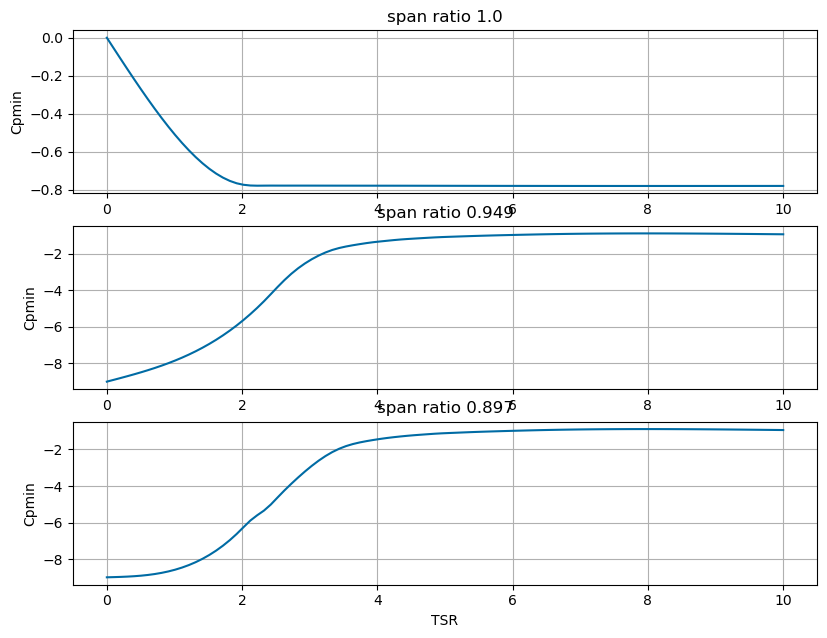

In [9]:
plt.figure(figsize=(6.4*1.5,4.8*1.5))
plt.subplot(3,1,1)
plt.plot(TSR_val,CpminFunc[0](TSR_val))
# plt.xlabel('TSR')
plt.ylabel('Cpmin')
plt.title('span ratio ' + str(spanRatio[0]))
plt.grid()

plt.subplot(3,1,2)
plt.plot(TSR_val,CpminFunc[1](TSR_val))
# plt.xlabel('TSR')
plt.ylabel('Cpmin')
plt.title('span ratio ' + str(round(spanRatio[1],3)))
plt.grid()

plt.subplot(3,1,3)
plt.plot(TSR_val,CpminFunc[2](TSR_val))
plt.xlabel('TSR')
plt.ylabel('Cpmin')
plt.title('span ratio ' + str(round(spanRatio[2],3)))
plt.grid()

plt.savefig("Cpmin.pdf", format="pdf", bbox_inches="tight")


The function file also contains function to estimate blade volume from Aerodyne data
- it uses the blade density in `constRotor.py` to estimate the blade's mass 

In [10]:
bladeVolume,bladeMass,bladeRadius,bladeCoordinate = funcRotor.estimateRotorMass(AeroDynFolderPath) 

print('The single blade has estimated volume ' + str(round(bladeVolume*CONVERT.m32cm3,3)) + ' cm^3 with mass ' + str(round(bladeMass,3)) +  ' kg and radius ' + str(round(bladeRadius,3)) + ' m')

The single blade has estimated volume 228.359 cm^3 with mass 0.685 kg and radius 0.258 m


We can visualise the blade geometry to check if the data was process correctly

(-0.1, 0.25)

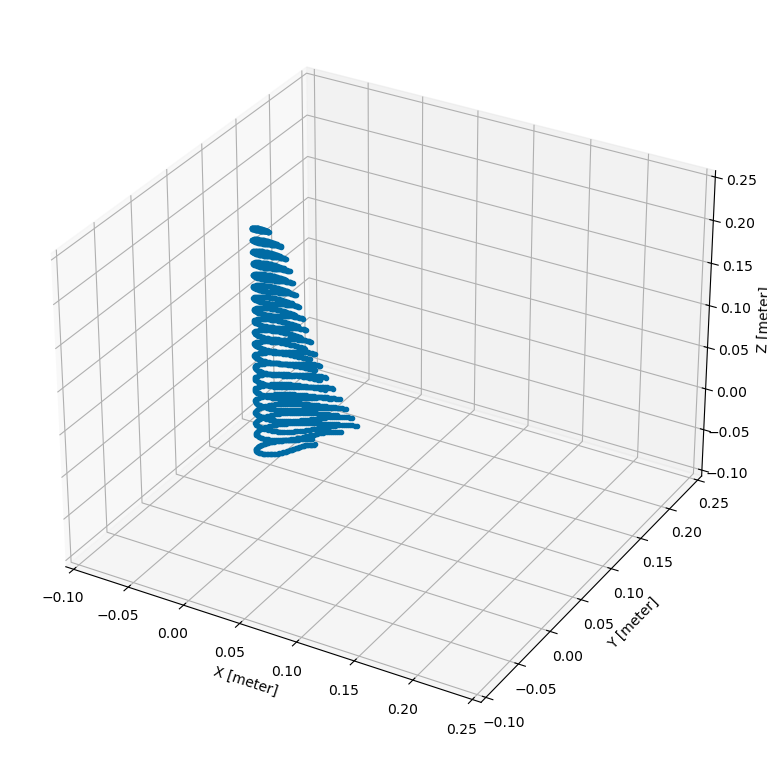

In [11]:
fig = plt.figure(figsize=(6.4*1.5,4.8*2))
ax = plt.axes(projection='3d')
# Plot defining corner points
ax.plot(bladeCoordinate.T[0], bladeCoordinate.T[1], bladeCoordinate.T[2],'.')

ax.set_xlabel('X [meter]')
ax.set_ylabel('Y [meter]')
ax.set_zlabel('Z [meter]')
ax.set_xlim([-0.1, 0.25])
ax.set_ylim([-0.1, 0.25])
ax.set_zlim([-0.1, 0.25])

The file `funcRotor` contains function to scale the rotor inertia given desired radius. 

Example: Radius of 0.5 [m] has moment of inertia of 1.250662324005989 [kg m2]


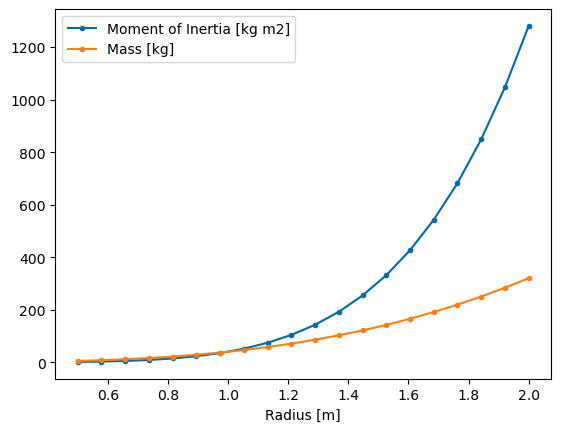

In [17]:
Rr_val = np.linspace(0.5,2.0,20) # Define Radius 
Jr_val,Mass_val = funcRotor.calInertia(Rr_val,bladeRadius,bladeMass,2) # Calculate 

plt.figure()

plt.plot(Rr_val,Jr_val,'.-',label='Moment of Inertia [kg m2]')
plt.plot(Rr_val,Mass_val,'.-',label='Mass [kg]')
plt.xlabel('Radius [m]')
plt.legend()

print('Example: Radius of ' + str(Rr_val[0]) + ' [m] has moment of inertia of ' + str(Jr_val[0]) + ' [kg m2]')
plt.savefig("ScaleInertia.pdf", format="pdf", bbox_inches="tight")
